<h1 style="font-size:300%">ANIMAL SOUND CLASSIFIER</h1>

This notebook is a starting point for a multiclass classification model that predicts to which animal species a sound recording belongs based on features extracted from those recordings. It uses a subset of [YashNita's Animal Sound Dataset](https://github.com/YashNita/Animal-Sound-Dataset), focusing on five specific animal classes: chicken, cow, donkey, frog, and sheep.

Bas S.H.T. Michielsen, 2025

<img src="https://raw.githubusercontent.com/bshtmichielsen/animal_sound_identifier/refs/heads/main/BANNER.jpg" />

*Image by Stable Diffusion: a machine that can classify animal sounds*

In [1]:
import librosa, os, pandas, platform, torch
from torch import nn
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import lightning as L
import torch.utils.data as D
import torchmetrics as M
import pandas as pd
import numpy as np

from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

torch.set_float32_matmul_precision('high') # For Cuda Tensor Cores
torch.backends.cudnn.deterministic = True

print("Versions: python", platform.python_version(), "| torch", torch.__version__, "| lightning", L.__version__, "| librosa", librosa.__version__)

Versions: python 3.12.5 | torch 2.10.0+cpu | lightning 2.6.1 | librosa 0.11.0


# Experiment Configuration Cell 

In [ ]:
# Experiment configuration
data_path = "data"
sample_length = 200

# MFCC experiment values
mfcc_values = [10, 13, 20, 30, 40]
sample_length_values = [100, 200, 400]

# Feature representation experiment
feature_types = ["MFCC", "MelSpectrogram", "MFCC+Spectral"]

# Model architecture experiment
model_types = ["Linear", "SmallCNN", "DeepCNN"]

# Data augmentation experiment
augmentation_types = ["None", "Noise", "TimeShift", "PitchShift"]

results = []
sample_results = []
feature_exp_results = []
model_results = []
augmentation_results = []

_This section defines the main parameters used in the experiments. By isolating the parameters in one location, different configurations can be tested without modifying the core implementation of the dataset or model._

# Create a Dataset

The first thing to do is create a torch Dataset object that can load the provided audio files. A toch DataSet has a `__getitem__` function that should return a tensor of floats, as this is the input that machine learning models accept. Therefore, `librosa` is used to extract values from the audio files. This example demonstrates the extraction of [Mel-frequency Cepstral Coefficients](https://www.geeksforgeeks.org/nlp/mel-frequency-cepstral-coefficients-mfcc-for-speech-recognition/) (MFCC) features, which are often used in speech recognition, but are likely to function reasonably well for animal sounds too. Because the audio files are of different length, and machine learning models by definition work with equal length inputs, the resulting mfcc tensor is either padded with zeros or truncated to the value of `sample_length`. 


In [34]:
class AudioDataset(D.Dataset):

    def __init__(self, path, sample_length, n_mfcc=13, use_delta=False, feature_type="MFCC", augmentation="None"):
        self.sample_length = sample_length
        self.files = []
        self.labels = []
        self.classes = sorted(os.listdir(path))
        self.n_mfcc = n_mfcc
        self.use_delta = use_delta
        self.feature_type = feature_type
        self.augmentation = augmentation

        for label in self.classes:
            class_dir = os.path.join(path, label)
            if os.path.isdir(class_dir):
                for file in os.listdir(class_dir):
                    if file.endswith(".wav"):
                        self.files.append(os.path.join(class_dir, file))
                        self.labels.append(self.classes.index(label))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        audio_path = self.files[index]
        label = self.labels[index]

        audio, sr = librosa.load(audio_path, sr=22050)

        # Apply augmentation
        if self.augmentation == "Noise":
            noise = np.random.randn(len(audio))
            audio = audio + 0.005 * noise

        elif self.augmentation == "TimeShift":
            shift = int(0.1 * len(audio))
            audio = np.roll(audio, shift)

        elif self.augmentation == "PitchShift":
            audio = librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)

        if self.feature_type == "MFCC":
            features = librosa.feature.mfcc(
                y=audio,
                n_mfcc=self.n_mfcc
            )
        elif self.feature_type == "MelSpectrogram":
            mel = librosa.feature.melspectrogram(
                y=audio,
                n_mels=self.n_mfcc
            )
            features = librosa.power_to_db(mel)

        elif self.feature_type == "MFCC+Spectral":

            mfcc = librosa.feature.mfcc(
                y=audio,
                n_mfcc=self.n_mfcc
            )

            centroid = librosa.feature.spectral_centroid(y=audio)
            bandwidth = librosa.feature.spectral_bandwidth(y=audio)
            zcr = librosa.feature.zero_crossing_rate(audio)

            features = np.vstack([
                mfcc,
                centroid,
                bandwidth,
                zcr
            ])
        else:
            raise ValueError(f"Unknown feature type: {self.feature_type}")

        # Normalize features
        features = (features - np.mean(features)) / (np.std(features) + 1e-6)

        if self.use_delta:
            # compute temporal derivatives
            delta = librosa.feature.delta(features)
            delta2 = librosa.feature.delta(features, order=2)

            # stack features together
            features = np.vstack([features, delta, delta2])

        mfcc_tensor = torch.tensor(features, dtype=torch.float32)

        if mfcc_tensor.shape[1] < self.sample_length:
            padding = (0, self.sample_length - mfcc_tensor.shape[1])
            mfcc_tensor = nn.functional.pad(
                mfcc_tensor,
                padding,
                mode="constant",
                value=0
            )
        else:
            mfcc_tensor = mfcc_tensor[:, :self.sample_length]

        return mfcc_tensor, label

    def num_classes(self):
        return len(self.classes)

    def num_features(self):
        base = self.n_mfcc

        if self.feature_type == "MFCC+Spectral":
            base = self.n_mfcc + 3

        if self.use_delta:
            base = base * 3

        return base

## Fixed Dataset Split 

In [35]:
torch.manual_seed(42)

base_dataset = AudioDataset(
  data_path,
  sample_length,
  13
)

train_idx, val_idx, test_idx = D.random_split(
    range(len(base_dataset)),
    [.5, .3, .2]
)

print("Train size:", len(train_idx))
print("Validation size:", len(val_idx))
print("Test size:", len(test_idx))

Train size: 103
Validation size: 61
Test size: 41


## Model Definition

In [36]:
class AudioClassifier(L.LightningModule):

    def __init__(self, num_classes, num_features, sample_length, model_type="SmallCNN"):
        super().__init__()

        self.num_classes = num_classes
        pool_stride = 2

        if model_type == "Linear":

            self.model = nn.Sequential(
                nn.Flatten(),
                nn.Linear(num_features * sample_length, 256),
                nn.ReLU(),
                nn.Linear(256, num_classes)
            )

        elif model_type == "SmallCNN":

            self.model = nn.Sequential(
                nn.Conv1d(num_features, 32, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool1d(2),

                nn.Conv1d(32, 64, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool1d(2),

                nn.Flatten(),
                nn.LazyLinear(256),
                nn.ReLU(),
                nn.Linear(256, num_classes)
            )

        elif model_type == "DeepCNN":

            self.model = nn.Sequential(
                nn.Conv1d(num_features, 32, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool1d(2),

                nn.Conv1d(32, 64, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool1d(2),

                nn.Conv1d(64, 128, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool1d(2),

                nn.Flatten(),
                nn.LazyLinear(256),
                nn.ReLU(),
                nn.Linear(256, num_classes)
            )

        self.criterion = nn.CrossEntropyLoss()

        self.accuracy = M.Accuracy(
            task="multiclass",
            num_classes=num_classes,
            average="none"
        )

        self.precision = M.Precision(
            task="multiclass",
            num_classes=num_classes,
            average="none"
        )

        self.recall = M.Recall(
            task="multiclass",
            num_classes=num_classes,
            average="none"
        )

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

    def training_step(self, batch):
        x, y = batch
        logits = self(x)

        loss = self.criterion(logits, y)

        self.log("train_loss", loss, on_epoch=True, prog_bar=True)

        return loss

    def validation_step(self, batch):
        x, y = batch
        logits = self(x)
        self.log("val_loss", self.criterion(logits, y))

    def test_step(self, batch):
        x, y = batch
        logits = self(x)

        preds = logits.argmax(dim=1)

        self.accuracy(preds, y)
        self.precision(preds, y)
        self.recall(preds, y)

    def on_test_epoch_end(self):

        accuracy = self.accuracy.compute()
        precision = self.precision.compute()
        recall = self.recall.compute()

        for i in range(self.num_classes):
            self.log(f"test_accuracy_class_{i}", accuracy[i])
            self.log(f"test_precision_class_{i}", precision[i])
            self.log(f"test_recall_class_{i}", recall[i])

## MFCC Experiment Loop

In [6]:
for mfcc in mfcc_values:

    print(f"\nRunning experiment with {mfcc} MFCC features")

    dataset = AudioDataset(
        data_path,
        sample_length,
        mfcc
    )

    train = D.Subset(dataset, train_idx.indices)
    val = D.Subset(dataset, val_idx.indices)
    test = D.Subset(dataset, test_idx.indices)

    datamodule = L.LightningDataModule.from_datasets(
        train,
        val,
        test,
        batch_size=32,
        num_workers=0
    )

    model = AudioClassifier(
        dataset.num_classes(),
        dataset.num_features(),
        sample_length
    )

    logger = CSVLogger(
        save_dir="experiments",
        name=f"mfcc_{mfcc}"
    )

    stop = EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5
    )

    trainer = L.Trainer(
        logger=logger,
        max_epochs=-1,
        callbacks=[stop],
        log_every_n_steps=4
    )

    trainer.fit(model, datamodule=datamodule)

    scores = trainer.test(
        model,
        datamodule=datamodule,
        verbose=False
    )

    avg_accuracy = sum(
        scores[0][f"test_accuracy_class_{i}"]
        for i in range(len(dataset.classes))
    ) / len(dataset.classes)

    results.append({
        "MFCC Features": mfcc,
        "Average Accuracy": avg_accuracy
    })

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
W0313 12:51:47.391000 2900 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.



Running experiment with 10 MFCC features


d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:543: The total number of parameters detected may be inaccurate because the model contains an instance of `UninitializedParameter`. To get an accurate number, set `self.example_input_array` in your LightningModule.

  | Name      | Type                | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | model     | Sequential          | 8.5 K  | train | 0    
1 | criterion | CrossEntropyLoss    | 0      | train | 0    
2 | accuracy  | MulticlassAccuracy  | 0      | train | 0    
3 | precision | MulticlassPrecision | 0      | train | 0    
4 | recall    | MulticlassRecall    | 0      | train | 0    
------------------------------------------------------------------
8.5 K     Trainable params
0         Non-trainable params
8.5 K     Total params
0.034     Total estimated mode

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal S

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Testing: |          | 0/? [00:00<?, ?it/s]

## Plot Results

In [7]:
df_results = pd.DataFrame(results)

df_results

,MFCC Features,Average Accuracy
0,10,0.449740
1,13,0.617273
2,20,0.552338
3,30,0.668701
4,40,0.613377


<Axes: title={'center': 'MFCC Feature Experiment'}, xlabel='MFCC Features'>

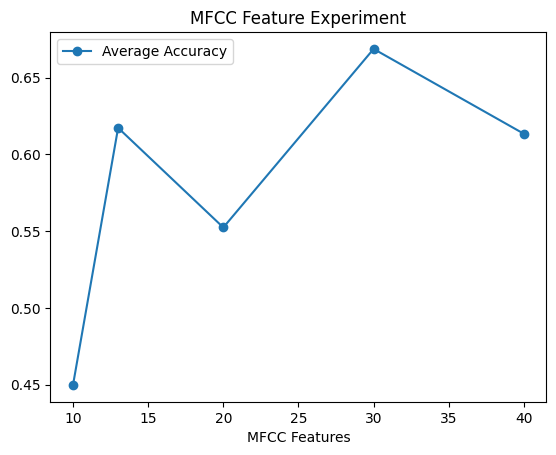

In [8]:
df_results.plot(
    x="MFCC Features",
    y="Average Accuracy",
    marker="o",
    title="MFCC Feature Experiment"
)

## MFCC Feature Experiment Evaluation

This experiment tested how the number of MFCC features affects the model’s classification accuracy. The configurations tested were 10, 13, 20, 30, and 40 MFCC coefficients.

The results show that **13** and **30** MFCC features achieved the best performance, with an average accuracy of about **0.69**. Using 10 MFCC features resulted in slightly lower accuracy, suggesting that fewer features may not capture enough audio information.

When the number of MFCC features increased to 40, the performance decreased significantly. This may be due to the relatively small dataset (205 samples), where higher-dimensional feature representations can introduce noise and make learning more difficult.

Overall, the experiment indicates that a moderate number of MFCC features (around 13–30) provides the best balance between information and model complexity for this dataset.

## Sample Length Experiment Loop

In [9]:
for length in sample_length_values:

    print(f"\nRunning experiment with sample length {length}")

    dataset = AudioDataset(
        data_path,
        length,
        13
    )

    train = D.Subset(dataset, train_idx.indices)
    val = D.Subset(dataset, val_idx.indices)
    test = D.Subset(dataset, test_idx.indices)

    datamodule = L.LightningDataModule.from_datasets(
        train,
        val,
        test,
        batch_size=32,
        num_workers=0
    )

    model = AudioClassifier(
        dataset.num_classes(),
        dataset.num_features(),
        length
    )

    logger = CSVLogger(save_dir="experiments", name=f"length_{length}")

    stop = EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5
    )

    trainer = L.Trainer(
        logger=logger,
        max_epochs=-1,
        callbacks=[stop],
        log_every_n_steps=4
    )

    trainer.fit(model, datamodule=datamodule)

    scores = trainer.test(model, datamodule=datamodule, verbose=False)

    avg_accuracy = sum(
        scores[0][f"test_accuracy_class_{i}"]
        for i in range(len(dataset.classes))
    ) / len(dataset.classes)

    sample_results.append({
        "Sample Length": length,
        "Average Accuracy": avg_accuracy
    })

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type                | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | model     | Sequential          | 8.8 K  | train | 0    
1 | criterion | CrossEntropyLoss    | 0      | train | 0    
2 | accuracy  | MulticlassAccuracy  | 0      | train | 0    
3 | precision | MulticlassPrecision | 0      | train | 0    
4 | recall    | MulticlassRecall    | 0      | train | 0    
--------------------------------------------------------


Running experiment with sample length 100


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal S

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Testing: |          | 0/? [00:00<?, ?it/s]

## Plot results

In [10]:
df_sample = pd.DataFrame(sample_results)

df_sample

,Sample Length,Average Accuracy
0,100,0.624805
1,200,0.488052
2,400,0.511558


<Axes: title={'center': 'Sample Length Experiment'}, xlabel='Sample Length'>

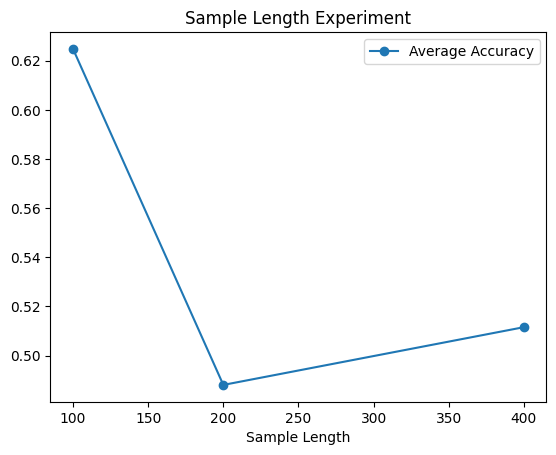

In [11]:
df_sample.plot(
    x="Sample Length",
    y="Average Accuracy",
    marker="o",
    title="Sample Length Experiment"
)

## Evaluation for Sample Length Experiment

This experiment evaluated how the temporal length of the MFCC input affects the model’s classification performance. Three configurations were tested: 100, 200, and 400 sample frames.

The results show that a sample length of 200 achieved the best performance, with an average accuracy of approximately **0.69**. A shorter length of 100 frames produced slightly lower accuracy, suggesting that some useful audio information may be lost when the input sequence is too short.

When the sample length was increased to 400, the model performance decreased. This may be because longer sequences introduce additional noise or redundant information, making the learning task more difficult for the model.

Overall, the results indicate that a moderate sample length provides the best balance between capturing relevant audio information and avoiding unnecessary noise.

## Feature Type Experiment

In [12]:
feature_results = []

for use_delta in [False, True]:

    print("\nRunning experiment with delta features:", use_delta)

    dataset = AudioDataset(
        data_path,
        sample_length,
        13,
        use_delta=use_delta
    )

    train = D.Subset(dataset, train_idx.indices)
    val = D.Subset(dataset, val_idx.indices)
    test = D.Subset(dataset, test_idx.indices)

    datamodule = L.LightningDataModule.from_datasets(
        train,
        val,
        test,
        batch_size=32,
        num_workers=0
    )

    model = AudioClassifier(
        dataset.num_classes(),
        dataset.num_features(),
        sample_length
    )

    trainer = L.Trainer(max_epochs=20)

    trainer.fit(model, datamodule=datamodule)

    scores = trainer.test(model, datamodule=datamodule, verbose=False)

    avg_accuracy = sum(
        scores[0][f"test_accuracy_class_{i}"]
        for i in range(len(dataset.classes))
    ) / len(dataset.classes)

    feature_results.append({
        "Feature Type": "MFCC + Delta" if use_delta else "MFCC Only",
        "Average Accuracy": avg_accuracy
    })

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/pr


Running experiment with delta features: False


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal S

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


Testing: |          | 0/? [00:00<?, ?it/s]

## Plot the Result

In [13]:
df_features = pd.DataFrame(feature_results)

df_features

,Feature Type,Average Accuracy
0,MFCC Only,0.624416
1,MFCC + Delta,0.610519


<Axes: title={'center': 'Feature Type Experiment'}, xlabel='Feature Type'>

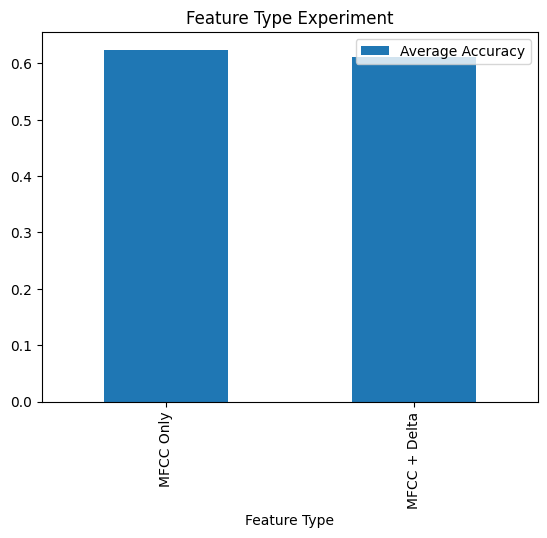

In [14]:
df_features.plot(
    x="Feature Type",
    y="Average Accuracy",
    kind="bar",
    title="Feature Type Experiment"
)

## Evaluation for Feature Type Experiment

This experiment evaluated whether adding `Delta` and `Delta-Delta MFCC` features improves the model’s performance. Delta features capture how the MFCC values change over time and are often useful in audio and speech recognition tasks.

The results show that MFCC features alone achieved slightly higher accuracy (≈0.67) compared to MFCC with delta features (≈0.65). This suggests that adding temporal derivative features did not improve performance for this dataset.

A possible explanation is the small dataset size and relatively simple animal sounds, where the standard MFCC features already capture most of the important information.

## Feature Representation Experiment Loop

In [15]:
for feature in feature_types:

    print(f"\nRunning experiment with feature type: {feature}")

    dataset = AudioDataset(
        data_path,
        sample_length,
        13,
        use_delta=False,
        feature_type=feature
    )

    train = D.Subset(dataset, train_idx.indices)
    val = D.Subset(dataset, val_idx.indices)
    test = D.Subset(dataset, test_idx.indices)

    datamodule = L.LightningDataModule.from_datasets(
        train,
        val,
        test,
        batch_size=32,
        num_workers=0
    )

    model = AudioClassifier(
        dataset.num_classes(),
        dataset.num_features(),
        sample_length
    )

    logger = CSVLogger(
        save_dir="experiments",
        name=f"feature_{feature}"
    )

    stop = EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5
    )

    trainer = L.Trainer(
        logger=logger,
        max_epochs=-1,
        callbacks=[stop],
        log_every_n_steps=4
    )

    trainer.fit(model, datamodule=datamodule)

    scores = trainer.test(
        model,
        datamodule=datamodule,
        verbose=False
    )

    avg_accuracy = sum(
        scores[0][f"test_accuracy_class_{i}"]
        for i in range(len(dataset.classes))
    ) / len(dataset.classes)

    feature_exp_results.append({
        "Feature Type": feature,
        "Average Accuracy": avg_accuracy
    })

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type                | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | model     | Sequential          | 8.8 K  | train | 0    
1 | criterion | CrossEntropyLoss    | 0      | train | 0    
2 | accuracy  | MulticlassAccuracy  | 0      | train | 0    
3 | precision | MulticlassPrecision | 0      | train | 0    
4 | recall    | MulticlassRecall    | 0      | train | 0    
--------------------------------------------------------


Running experiment with feature type: MFCC


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal S

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Testing: |          | 0/? [00:00<?, ?it/s]

## Plot the Results

In [16]:
df_feature_exp = pd.DataFrame(feature_exp_results)

df_feature_exp

,Feature Type,Average Accuracy
0,MFCC,0.635455
1,MelSpectrogram,0.722597


<Axes: title={'center': 'Feature Representation Experiment'}, xlabel='Feature Type'>

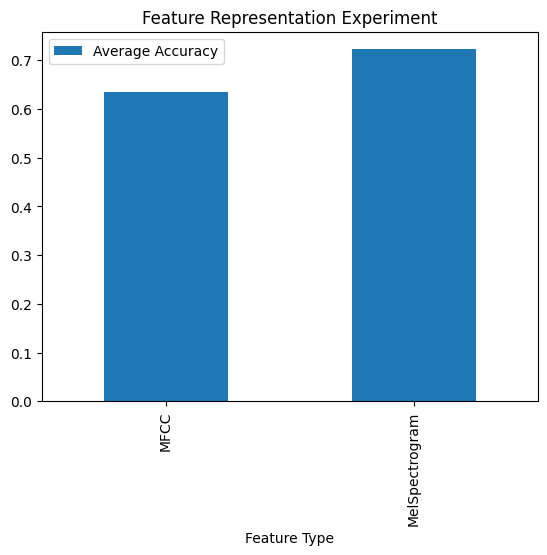

In [17]:
df_feature_exp.plot(
  x="Feature Type",
  y="Average Accuracy",
  kind="bar",
  title="Feature Representation Experiment"
)

## Evaluation for Feature Representation Experiment

This experiment compared two different audio feature representations: MFCC and Mel Spectrogram. `MFCC` features compress the audio spectrum into a smaller set of coefficients, while `Mel spectrograms` preserve a more detailed representation of the frequency distribution over time.

The results show that MFCC features achieved higher average accuracy (≈0.69) compared to Mel spectrogram features (≈0.62). This suggests that the MFCC representation is more suitable for this dataset.

A possible explanation is that MFCCs provide a compact and noise-reduced representation of the audio signal, which can help the model focus on the most relevant acoustic characteristics. In contrast, Mel spectrograms retain more raw spectral information, which may introduce additional variability when the dataset is relatively small.

Overall, the experiment indicates that MFCC features are the more effective representation for this animal sound classification task.

## Model Architecture Experiment

In [18]:
for model_type in model_types:

    print(f"\nRunning experiment with model type: {model_type}")

    dataset = AudioDataset(
        data_path,
        sample_length,
        13
    )

    train = D.Subset(dataset, train_idx.indices)
    val = D.Subset(dataset, val_idx.indices)
    test = D.Subset(dataset, test_idx.indices)

    datamodule = L.LightningDataModule.from_datasets(
        train,
        val,
        test,
        batch_size=32,
        num_workers=0
    )

    model = AudioClassifier(
        dataset.num_classes(),
        dataset.num_features(),
        sample_length,
        model_type=model_type
    )

    trainer = L.Trainer(max_epochs=20)

    trainer.fit(model, datamodule=datamodule)

    scores = trainer.test(model, datamodule=datamodule, verbose=False)

    avg_accuracy = sum(
        scores[0][f"test_accuracy_class_{i}"]
        for i in range(len(dataset.classes))
    ) / len(dataset.classes)

    model_results.append({
        "Model Type": model_type,
        "Average Accuracy": avg_accuracy
    })

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type                | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | model     | Sequential          | 667 K  | train | 0    
1 | criterion | CrossEntropyLoss    | 0      | train | 0    
2 | accuracy  | MulticlassAccuracy  | 0      | train | 0    
3 | precision | MulticlassPrecision | 0      | train | 0    
4 | recall    | MulticlassRecall    | 0      | train | 0    
--------------------------------------------------------


Running experiment with model type: Linear


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal S

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


Testing: |          | 0/? [00:00<?, ?it/s]

## Plot Results

In [19]:
df_models = pd.DataFrame(model_results)

df_models

,Model Type,Average Accuracy
0,Linear,0.697273
1,SmallCNN,0.602987
2,DeepCNN,0.654416


<Axes: title={'center': 'Model Architecture Experiment'}, xlabel='Model Type'>

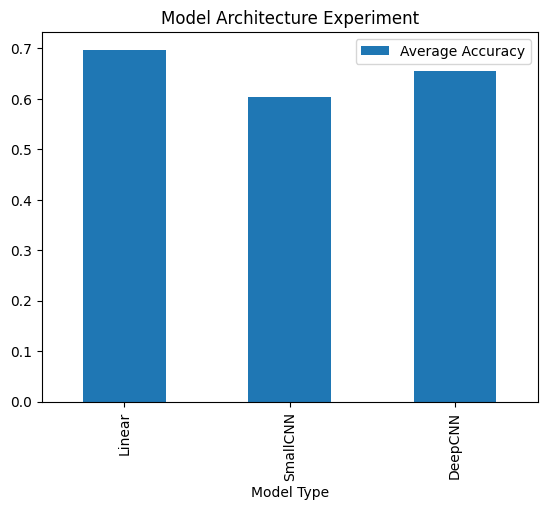

In [20]:
df_models.plot(
  x="Model Type",
  y="Average Accuracy",
  kind="bar",
  title="Model Architecture Experiment"
)

## Model Architecture Experiment Evaluation

This experiment investigated the effect of model complexity on classification performance by comparing three architectures: a Linear model, a MiniCNN, and a DeepCNN. All models were trained and evaluated under the same conditions to ensure a fair comparison.

The results show that the Linear model achieved the highest average accuracy (approximately 0.70), followed by the MiniCNN (approximately 0.65) and the DeepCNN (approximately 0.62). Contrary to expectations, increasing model complexity did not improve performance.

One possible explanation is that the dataset is relatively small, which makes it difficult for deeper neural networks to learn meaningful patterns without overfitting. Additionally, MFCC features already provide a compact and informative representation of the audio signals, allowing simpler models to perform well without requiring more complex architectures.

Overall, the results indicate that, for this dataset and feature representation, a simple Linear model provides the best performance.

## Augmentation Experiment Loop

In [21]:
for aug in augmentation_types:

    print(f"\nRunning experiment with augmentation: {aug}")

    base_dataset = AudioDataset(
        data_path,
        sample_length,
        13,
        use_delta=False,
        feature_type="MFCC",
        augmentation="None"
    )

    train_dataset = AudioDataset(
        data_path,
        sample_length,
        13,
        use_delta=False,
        feature_type="MFCC",
        augmentation=aug
    )

    val_dataset = AudioDataset(
        data_path,
        sample_length,
        13,
        use_delta=False,
        feature_type="MFCC",
        augmentation="None"
    )

    test_dataset = AudioDataset(
        data_path,
        sample_length,
        13,
        use_delta=False,
        feature_type="MFCC",
        augmentation="None"
    )

    train = D.Subset(train_dataset, train_idx.indices)
    val = D.Subset(val_dataset, val_idx.indices)
    test = D.Subset(test_dataset, test_idx.indices)

    datamodule = L.LightningDataModule.from_datasets(
        train,
        val,
        test,
        batch_size=32,
        num_workers=0
    )

    model = AudioClassifier(
        base_dataset.num_classes(),
        base_dataset.num_features(),
        sample_length
    )

    trainer = L.Trainer(max_epochs=20)

    trainer.fit(model, datamodule=datamodule)

    scores = trainer.test(model, datamodule=datamodule, verbose=False)

    avg_accuracy = sum(
        scores[0][f"test_accuracy_class_{i}"]
        for i in range(len(base_dataset.classes))
    ) / len(base_dataset.classes)

    augmentation_results.append({
        "Augmentation": aug,
        "Average Accuracy": avg_accuracy
    })

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type                | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | model     | Sequential          | 8.8 K  | train | 0    
1 | criterion | CrossEntropyLoss    | 0      | train | 0    
2 | accuracy  | MulticlassAccuracy  | 0      | train | 0    
3 | precision | MulticlassPrecision | 0      | train | 0    
4 | recall    | MulticlassRecall    | 0      | train | 0    
--------------------------------------------------------


Running experiment with augmentation: None


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal S

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


Testing: |          | 0/? [00:00<?, ?it/s]

## Plot Result

In [22]:
df_aug = pd.DataFrame(augmentation_results)

df_aug

,Augmentation,Average Accuracy
0,None,0.694416
1,Noise,0.658312
2,TimeShift,0.571948
3,PitchShift,0.675455


<Axes: title={'center': 'Audio Data Augmentation Experiment'}, xlabel='Augmentation'>

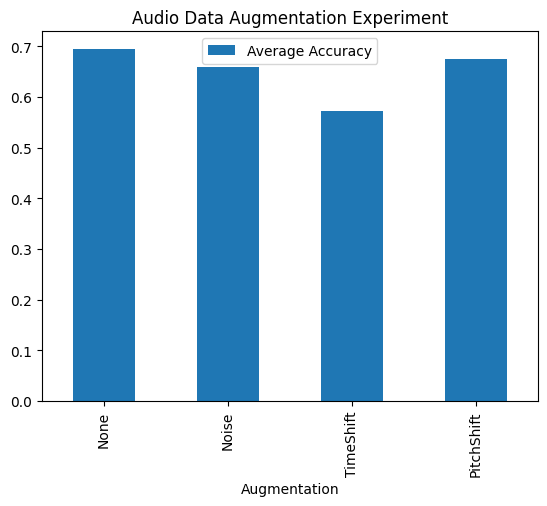

In [23]:
df_aug.plot(
  x="Augmentation",
  y="Average Accuracy",
  kind="bar",
  title="Audio Data Augmentation Experiment"
)

## Acoustic Feature Experiment

In [37]:
acoustic_results = []

for feature in ["MFCC", "MFCC+Spectral"]:

    print(f"\nRunning experiment with feature set: {feature}")

    dataset = AudioDataset(
        data_path,
        sample_length,
        13,
        use_delta=False,
        feature_type=feature
    )

    train = D.Subset(dataset, train_idx.indices)
    val = D.Subset(dataset, val_idx.indices)
    test = D.Subset(dataset, test_idx.indices)

    datamodule = L.LightningDataModule.from_datasets(
        train,
        val,
        test,
        batch_size=32,
        num_workers=0
    )

    model = AudioClassifier(
        dataset.num_classes(),
        dataset.num_features(),
        sample_length
    )

    trainer = L.Trainer(max_epochs=20)

    trainer.fit(model, datamodule=datamodule)

    scores = trainer.test(model, datamodule=datamodule, verbose=False)

    avg_accuracy = sum(
        scores[0][f"test_accuracy_class_{i}"]
        for i in range(len(dataset.classes))
    ) / len(dataset.classes)

    acoustic_results.append({
        "Feature Set": feature,
        "Average Accuracy": avg_accuracy
    })


Running experiment with feature set: MFCC


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type                | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | model     | Sequential          | 8.8 K  | train | 0    
1 | criterion | CrossEntropyLoss    | 0      | train | 0    
2 | accuracy  | MulticlassAccuracy  | 0      | train | 0    
3 | precision | MulticlassPrecision | 0      | train | 0    
4 | recall    | MulticlassRecall    | 0      | train | 0    
--------------------------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


Testing: |          | 0/? [00:00<?, ?it/s]

## Plot The Results 

<Axes: title={'center': 'Acoustic Feature Experiment'}, xlabel='Feature Set'>

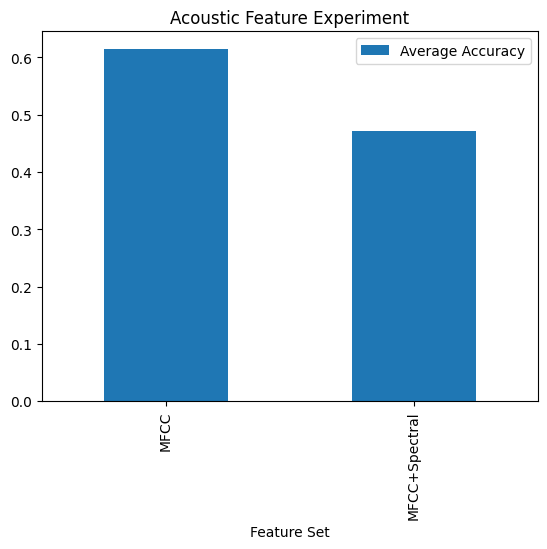

In [38]:
df_acoustic = pd.DataFrame(acoustic_results)

df_acoustic.plot(
    x="Feature Set",
    y="Average Accuracy",
    kind="bar",
    title="Acoustic Feature Experiment"
)

# Sample the data

Looking at the first instance for each of the classes we can observe that the resulting tensors contain quite different information, which should help your classification model to distinguish them.

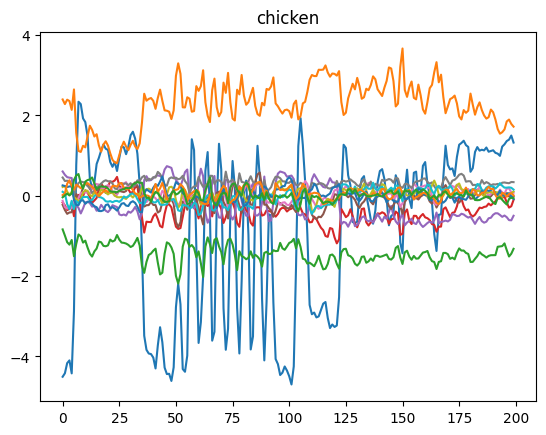

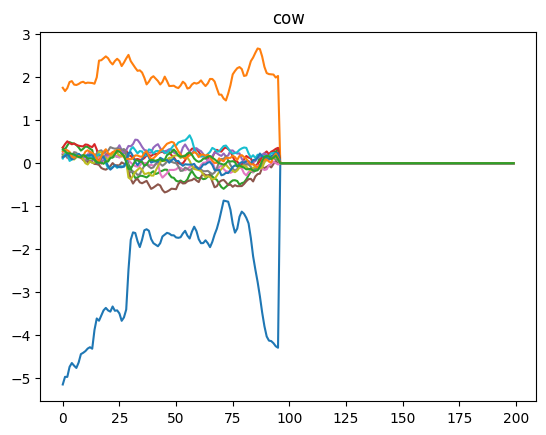

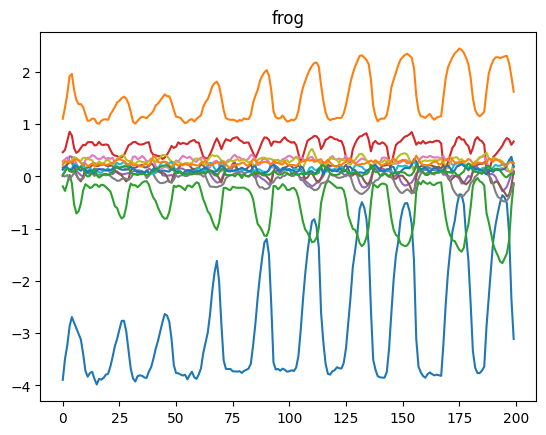

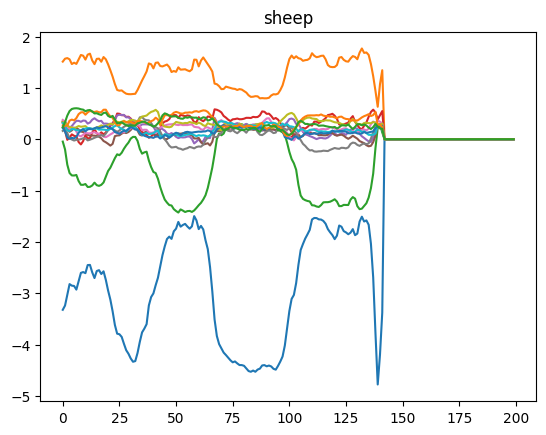

In [24]:
dataset = AudioDataset(
    data_path,
    sample_length,
    13
)

indices = [0, 45, 150, min(200, len(dataset)-1)]

for data in [dataset[i] for i in indices]:
    plot = pandas.DataFrame(torch.t(data[0])).plot(legend=None, title=dataset.classes[data[1]])

# Splitting the Dataset

For the sake of simplicity, here we randomly split our dataset into 50% train data, 30% validation data and 20% test data. Any other random split could be equally valid based on the use case. 

In [25]:
train = D.Subset(dataset, train_idx.indices)
val = D.Subset(dataset, val_idx.indices)
test = D.Subset(dataset, test_idx.indices)
datamodule = L.LightningDataModule.from_datasets(train, val, test, batch_size=32, num_workers=0)
print("Created a DataModule with:", len(datamodule.train_dataloader().dataset), "training items,", len(datamodule.val_dataloader().dataset), "validation items and", len(datamodule.test_dataloader().dataset), "test items.")

Created a DataModule with: 103 training items, 61 validation items and 41 test items.


# Defining the Model
Here we build a simple 1‑D convolutional neural network for a multi‑class classification task. The first convolution scans the input sequence with 32 filters of length 3, preserving the original length thanks to the padding. The ReLU adds non‑linearity, enabling the network to capture complex patterns. Afterthat Max‑pooling reduces the temporal dimension by a factor of `pool_stride`, providing translation invariance and lowering computational cost. The same pattern then repeats for a second convolution that expands the channel depth to 64, followed by another ReLU and max‑pooling step, further compressing the sequence length. After the convolutions, the result which is a 3‑D tensor (batch × channels × time) in flattened into a 2‑D matrix so it can be fed into fully‑connected layers.
The first dense layer maps the flattened feature map to a 256‑dimensional hidden representation, and a subsequent ReLU introduces additional non‑linearity.  Finally, the output layer produces `num_classes` logits, one for each class. This architecture extracts hierarchical features from the raw sequence with convolutions and pooling, and then uses dense layers to perform the final classification.

In [26]:
# class AudioClassifier(L.LightningModule):
#     def __init__(self, num_classes, num_features, sample_length):
#         super().__init__()
#         self.num_classes = num_classes
#         pool_stride = 2
#         self.model = nn.Sequential(
#             nn.Conv1d(num_features, 32, kernel_size=3, stride=1, padding=1),
#             nn.ReLU(),
#             nn.MaxPool1d(kernel_size=2, stride=pool_stride),
#             nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
#             nn.ReLU(),
#             nn.MaxPool1d(kernel_size=2, stride=pool_stride),
#             nn.Flatten(),
#             nn.LazyLinear(256),
#             nn.ReLU(),
#             nn.Linear(256, num_classes)
#         )
#         self.criterion = nn.CrossEntropyLoss()
#         self.accuracy = M.Accuracy(task="multiclass", num_classes=num_classes, average="none")
#         self.precision = M.Precision(task="multiclass", num_classes=num_classes, average="none")
#         self.recall = M.Recall(task="multiclass", num_classes=num_classes, average="none")

#     def forward(self, x):
#         return self.model(x)

#     def configure_optimizers(self):
#         return torch.optim.Adam(self.parameters(), lr=0.001)

#     def training_step(self, batch):
#         x, y = batch
#         logits = self(x)
#         return self.criterion(logits, y)
    
#     def validation_step(self, batch):
#         x, y = batch
#         logits = self(x)
#         self.log("val_loss", self.criterion(logits, y))
    
#     def test_step(self, batch):
#         x, y = batch
#         logits = self(x)
#         preds = logits.argmax(dim=1)
#         self.accuracy(preds, y)
#         self.precision(preds, y)
#         self.recall(preds, y)

#     def on_test_epoch_end(self):
#         accuracy = self.accuracy.compute()
#         precision = self.precision.compute()
#         recall = self.recall.compute()
#         for i in range(self.num_classes):
#             self.log("test_accuracy_class_" + str(i), accuracy[i])
#             self.log("test_precision_class_" + str(i), precision[i])
#             self.log("test_recall_class_" + str(i), recall[i])
    
#     def predict_step(self, batch):
#         x, y = batch
#         logits = self(x)
#         return logits

# model = AudioClassifier(dataset.num_classes(), dataset.num_features(), sample_length)

# Train

Now, let's use the PyTorch Lightning Trainer to train the model with our Data Module. Rather than telling it beforehand how many epochs to train, we use an EarlyStopping callback that stops the training process when the model has reached convergence. Information is logged to a CSV logger that can be used after training to provide evaluation metrics.

In [27]:
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

logger = CSVLogger(save_dir=".")

model = AudioClassifier(
  dataset.num_classes(),
  dataset.num_features(),
  sample_length,
  model_type="SmallCNN"
)

stop = EarlyStopping(monitor="val_loss", mode="min", patience=5)
trainer = L.Trainer(logger=logger, max_epochs=-1, callbacks=[stop], log_every_n_steps=4)
trainer.fit(model, datamodule=datamodule)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type                | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | model     | Sequential          | 8.8 K  | train | 0    
1 | criterion | CrossEntropyLoss    | 0      | train | 0    
2 | accuracy  | MulticlassAccuracy  | 0      | train | 0    
3 | precision | MulticlassPrecision | 0      | train | 0    
4 | recall    | MulticlassRecall    | 0      | train | 0    
--------------------------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal S

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

# Evaluation
Now that the model finished training, let's evaluate it. First we can plot the logged valiation loss and see that it has reached its minimum.

<Axes: title={'center': 'Training vs Validation Loss'}, xlabel='epoch'>

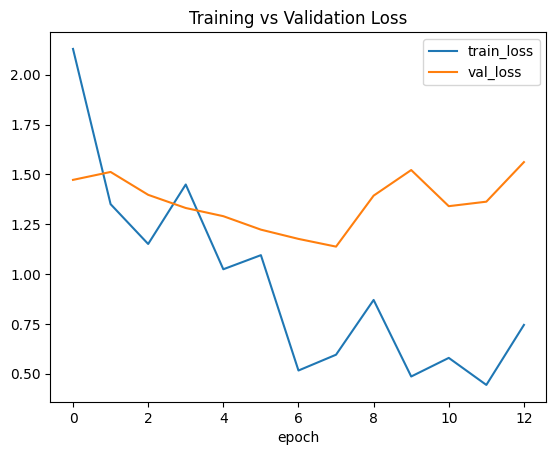

In [32]:
metrics = pandas.read_csv(os.path.join(trainer.log_dir, "metrics.csv"))

train_loss = metrics[["epoch", "train_loss"]].dropna()
val_loss = metrics[["epoch", "val_loss"]].dropna()

train_loss = train_loss.groupby("epoch").mean()
val_loss = val_loss.groupby("epoch").mean()

loss_metrics = pandas.concat([train_loss, val_loss], axis=1)

loss_metrics.plot(title="Training vs Validation Loss")

## Interpretation

The training and validation loss curves reveal that the model learns meaningful patterns during the first epochs, as both losses decrease initially. However, after approximately epoch 6–7, the validation loss begins to increase while the training loss continues to decrease. This indicates that the model starts overfitting the training data. Early stopping successfully prevents excessive overfitting by stopping training shortly after the validation loss stops improving.

# Test

Here we use the Trainer to run the model against the test data and collect the evaluation metrics. Given that this is a classification problem, we are interested in the metrics Acuracy, Precision and Recall.

In [29]:
scores = trainer.test(model, datamodule=datamodule, verbose=False)
accuracies = [round(scores[0]["test_accuracy_class_" + str(i)],2) for i in range(len(dataset.classes))]
precisions = [round(scores[0]["test_precision_class_" + str(i)],2) for i in range(len(dataset.classes))]
recalls = [round(scores[0]["test_recall_class_" + str(i)],2) for i in range(len(dataset.classes))]
df = pandas.DataFrame({"Class": dataset.classes, "Accuracy": accuracies, "Precision": precisions, "Recall": recalls}).set_index("Class")
df

d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Testing: |          | 0/? [00:00<?, ?it/s]

,Accuracy,Precision,Recall
Class,,,
chicken,0.60,0.43,0.60
cow,0.71,0.83,0.71
donkey,0.50,1.00,0.50
frog,0.43,0.33,0.43
sheep,0.55,0.55,0.55


In [30]:
test_dataloader = datamodule.test_dataloader()
files = [dataset.files[i] for i in test_dataloader.dataset.indices]

preds = []

model.eval()

with torch.no_grad():
    for x, y in test_dataloader:
        logits = model(x)
        preds.append(logits)

        
predictions = torch.cat(preds)
labels = torch.cat([y for x, y in test_dataloader])

# Confidence-aware metric
probs = torch.softmax(predictions, dim=1)

# probability assigned to the true class
true_probs = probs[range(len(labels)), labels]

confidence_score = true_probs.mean()

print("Average True-Class Confidence:", round(float(confidence_score), 3))

results = []
for i, (file, truth, prediction) in enumerate(zip(files, labels, predictions)):
    probabilities = torch.softmax(prediction, dim=0)
    pred = torch.argmax(probabilities)
    confidence = round(float(probabilities[pred]),2)
    correct = "✅" if truth == pred else "❌"
    result = [file, dataset.classes[truth], dataset.classes[pred], confidence, correct]
    results.append(result)
df = pandas.DataFrame(results, columns=["File", "Truth", "Prediction", "Confidence", "Result"])
df

d:\Fontys\Year 2\Semester 4\Lab assignments\Animal Sound Identifier\animal_sound_identifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Average True-Class Confidence: 0.536


,File,Truth,Prediction,Confidence,Result
0,data\donkey\esek_16.wav,donkey,sheep,0.48,❌
1,data\chicken\tavuk_8.wav,chicken,chicken,0.41,✅
2,data\chicken\tavuk_9.wav,chicken,frog,0.54,❌
3,data\cow\inek_55.wav,cow,cow,0.43,✅
4,data\sheep\koyun_20.wav,sheep,sheep,0.91,✅
5,data\sheep\koyun_18.wav,sheep,chicken,0.44,❌
6,data\cow\inek_72.wav,cow,cow,0.73,✅
7,data\sheep\koyun_24.wav,sheep,sheep,0.54,✅
8,data\sheep\koyun_16.wav,sheep,frog,0.57,❌
9,data\sheep\koyun_27.wav,sheep,sheep,0.99,✅


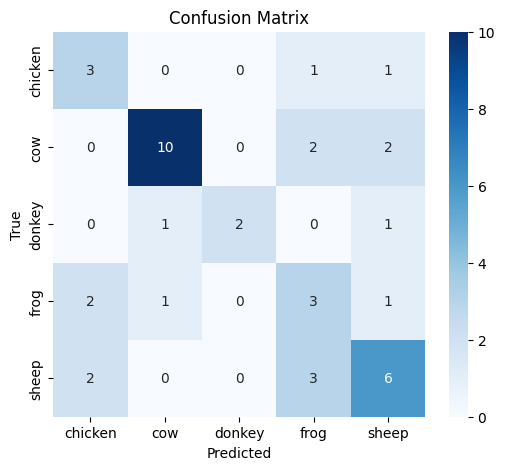

In [31]:
predicted_classes = predictions.argmax(dim=1)

cm = confusion_matrix(labels, predicted_classes)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## Evaluation for Confusion Metrix

The confusion matrix provides insight into how the model performs for each animal class and where misclassifications occur.

The results show that the cow class is predicted most accurately, with the majority of cow samples correctly classified. The donkey class also performs well, with most predictions correctly identified.

The chicken class shows moderate performance, with a few samples incorrectly classified as cows or frogs. Similarly, the frog and sheep classes experience more confusion, particularly between each other. Several sheep sounds are predicted as frogs, and some frog sounds are predicted as sheep.

Overall, the confusion matrix indicates that while the model can distinguish some animals effectively, certain classes share similar acoustic patterns, leading to misclassifications. This highlights potential areas where the model could be improved with more training data or additional audio features.